## 4.もっと推定を


### 4.1 ユーロ硬貨問題

ベルギーの１ユーロ硬貨を２５０回指で弾いて回してみたところ、表が140回、裏が１１０回出た。
硬貨は釣り合いが取れなくて偏っているか。


尤度関数

$ L(p) = p^{140}(1-p)^{110} $

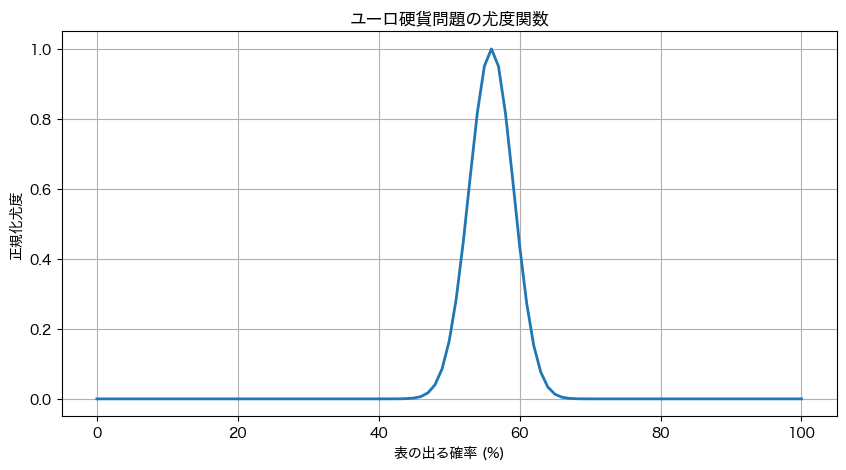

最大尤度仮説: H56
表の出る確率 = 56%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# データ
# -----------------------------
heads = 140
tails = 110

# 仮説 Hx
x = np.arange(0, 101)
p = x / 100

# -----------------------------
# 尤度
# -----------------------------
likelihood = np.zeros_like(p, dtype=float)

for i, prob in enumerate(p):
    if prob == 0:
        likelihood[i] = 1.0 if heads == 0 else 0.0
    elif prob == 1:
        likelihood[i] = 1.0 if tails == 0 else 0.0
    else:
        likelihood[i] = prob**heads * (1-prob)**tails

# 最大値で正規化
likelihood /= likelihood.max()

# -----------------------------
# グラフ
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(x, likelihood, lw=2)
plt.xlabel("表の出る確率 (%)")
plt.ylabel("正規化尤度")
plt.title("ユーロ硬貨問題の尤度関数")
plt.grid(True)
plt.show()

# 最大尤度仮説
best_x = x[np.argmax(likelihood)]

print(f"最大尤度仮説: H{best_x}")
print(f"表の出る確率 = {best_x}%")

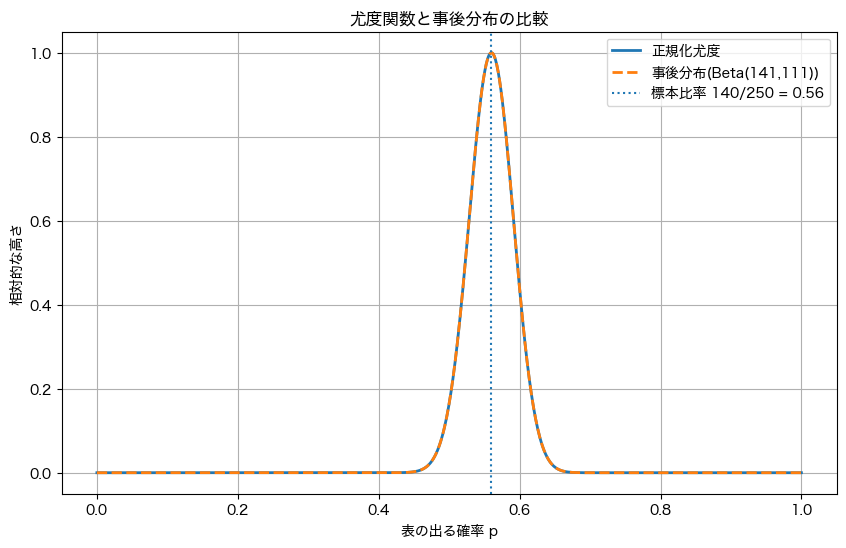

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 日本語フォント
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# データ
heads = 140
tails = 110

# p の連続値
p = np.linspace(0, 1, 1000)

# -------------------
# 尤度
# -------------------
likelihood = p**heads * (1-p)**tails

# 最大値で正規化
likelihood /= likelihood.max()

# -------------------
# 事後分布
# -------------------
posterior = beta.pdf(p, heads+1, tails+1)

# 最大値で正規化
posterior_scaled = posterior / posterior.max()

# -------------------
# グラフ
# -------------------
plt.figure(figsize=(10,6))

plt.plot(
    p,
    likelihood,
    label="正規化尤度",
    linewidth=2
)

plt.plot(
    p,
    posterior_scaled,
    "--",
    label="事後分布(Beta(141,111))",
    linewidth=2
)

plt.axvline(
    heads/(heads+tails),
    linestyle=":",
    label="標本比率 140/250 = 0.56"
)

plt.xlabel("表の出る確率 p")
plt.ylabel("相対的な高さ")
plt.title("尤度関数と事後分布の比較")
plt.grid(True)
plt.legend()

plt.show()

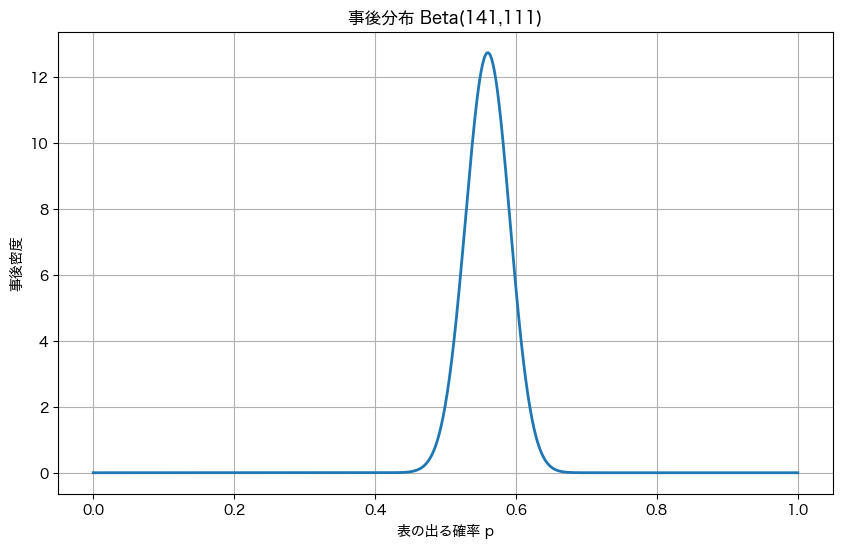

In [7]:
posterior = beta.pdf(p, 141, 111)

plt.figure(figsize=(10,6))
plt.plot(p, posterior, linewidth=2)

plt.xlabel("表の出る確率 p")
plt.ylabel("事後密度")
plt.title("事後分布 Beta(141,111)")
plt.grid(True)

plt.show()

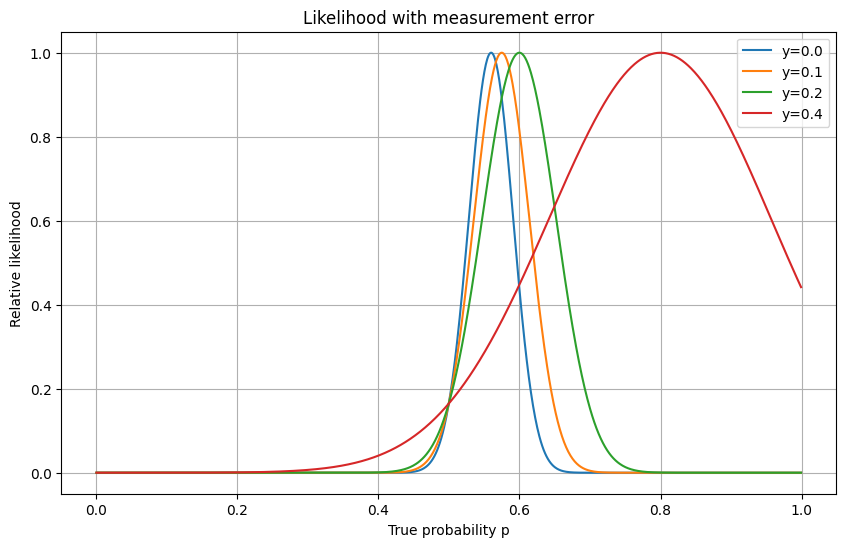

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 観測データ
heads = 140
tails = 110

# p の候補
p = np.linspace(0.001, 0.999, 1000)

# 誤り率
y_values = [0.0, 0.1, 0.2, 0.4]

plt.figure(figsize=(10, 6))

for y in y_values:

    # 観測上の表確率
    q = p * (1 - y) + (1 - p) * y

    # 尤度
    likelihood = q**heads * (1 - q)**tails

    # 正規化（見やすさのため最大値を1に）
    likelihood /= likelihood.max()

    plt.plot(p, likelihood, label=f"y={y}")

plt.xlabel("True probability p")
plt.ylabel("Relative likelihood")
plt.title("Likelihood with measurement error")
plt.legend()
plt.grid(True)
plt.show()

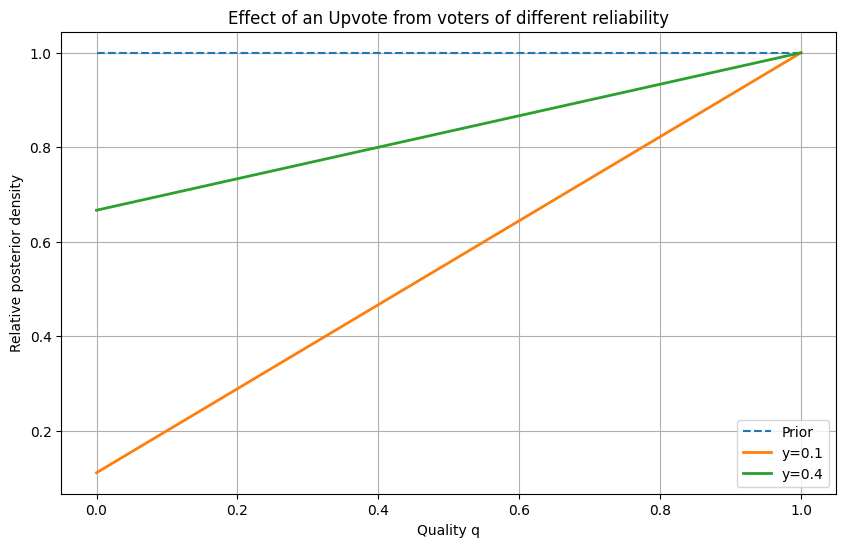

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 品質の候補
q = np.linspace(0, 1, 1000)

# 一様事前分布
prior = np.ones_like(q)

# 誤り率
y_values = [0.1, 0.4]

plt.figure(figsize=(10, 6))

# 事前分布
plt.plot(q, prior/prior.max(),
         '--',
         label='Prior')

for y in y_values:

    # Upvoteを1票観測したときの尤度
    likelihood = (1-y)*q + y*(1-q)

    # 事後分布
    posterior = prior * likelihood

    # 正規化
    posterior /= np.trapz(posterior, q)

    # 最大値を1にして比較しやすくする
    posterior /= posterior.max()

    plt.plot(
        q,
        posterior,
        linewidth=2,
        label=f'y={y}'
    )

plt.xlabel("Quality q")
plt.ylabel("Relative posterior density")
plt.title("Effect of an Upvote from voters of different reliability")
plt.grid(True)
plt.legend()
plt.show()

### 2.2 睡眠時間の十分な学生割合の調査

問題の整理：
* 求めたいもの：大学生が８時間以上睡眠をとる割合p
* 事前予測： $ p=0.3 $ ぐらい
* データ：27人中11人が８時間以上の睡眠


1. 事前分布

大体30%ぐらいだろう。

$ p \sim Beta(3,7) $

期待値：$ 3/(3+7) = 0.3 $

2. 尤度

$ L(p) \propto p^{11} (1-p)^{16} $

3. 事後分布

$ Beta(3+11,7+16) = Beta(13,23) $ 

未正規化分布の面積 = 4.741462285934833e-09
正規化分布の面積 = 1.0


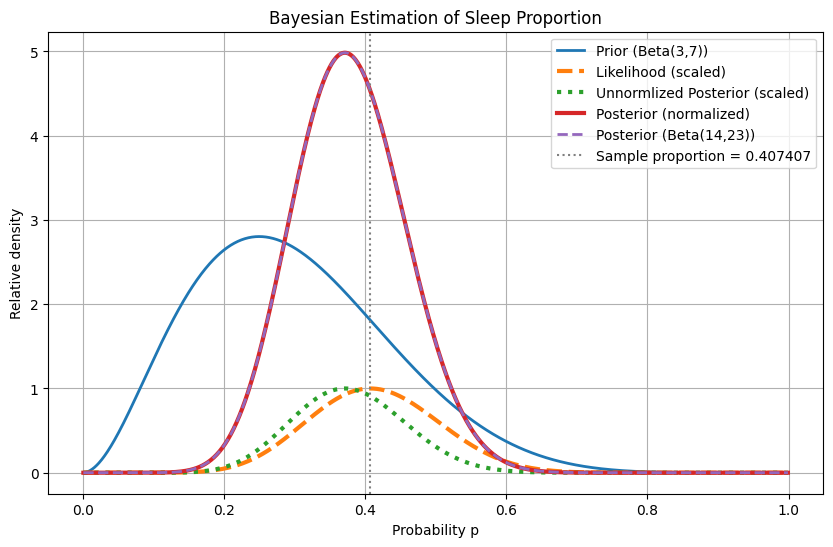

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# データ
n = 27
x = 11

# 事前分布
a_prior = 3
b_prior = 7

# 事後分布
a_post = a_prior + x
b_post = b_prior + (n-x)

# pの範囲
p = np.linspace(0.001, 0.999, 1000)

# 事前分布
prior = beta.pdf(p, a_prior, b_prior)

# 尤度
likelihood = p**x * (1-p)**(n-x)
likelihood_plot = likelihood / likelihood.max()


# 未正規化の事後分布
posterior_unnorm = prior * likelihood

# 正規化
area = np.trapz(posterior_unnorm, p)

print(f"未正規化分布の面積 = {area}")

posterior = posterior_unnorm /area

area2 = np.trapz(posterior, p)
print(f"正規化分布の面積 = {area2}")

# 共役事前分布による検算
a_post = a_prior + x
b_post = b_prior + (n - x)

# 事後分布
posterior_beta = beta.pdf(p, a_post, b_post)

# グラフ
plt.figure(figsize=(10, 6))
plt.plot(p, prior, label="Prior (Beta(3,7))", linewidth=2)
plt.plot(p, likelihood_plot, '--', linewidth=3, label="Likelihood (scaled)")
plt.plot(p, posterior_unnorm / posterior_unnorm.max(), ":", linewidth=3, label="Unnormlized Posterior (scaled)")
plt.plot(p, posterior, linewidth=3, label="Posterior (normalized)")
plt.plot(p, posterior_beta, '--', linewidth=2, label="Posterior (Beta(14,23))")
plt.axvline(x/n, color='gray', linestyle=':', label=f"Sample proportion = {x/n:3f}")

plt.xlabel("Probability p")
plt.ylabel("Relative density")
plt.title("Bayesian Estimation of Sleep Proportion")
plt.grid(True)
plt.legend()

